In [2]:
import pandas as pd
import matplotlib.pyplot as plt

file57 = pd.read_csv('fangraphs-leaderboards (57).csv')
file59 = pd.read_csv('fangraphs-leaderboards (59).csv')
file60 = pd.read_csv('fangraphs-leaderboards (60).csv')
file62 = pd.read_csv('fangraphs-leaderboards (62).csv')

print(file57.shape, file59.shape, file60.shape, file62.shape)

(72, 24) (72, 15) (72, 16) (72, 21)


In [3]:
base = file57[['Name', 'Team', 'PlayerId', 'PA', 'wRC+', 'ISO', 'K%', 'BB%']]
value = file60[['PlayerId', 'WAR']]
wp = file59[['PlayerId', 'WPA', 'Clutch']]
sc = file62[['PlayerId', 'EV', 'Barrel%', 'HardHit%', 'xwOBA', 'xSLG']]

full = base.merge(value, on='PlayerId').merge(wp, on='PlayerId').merge(sc, on='PlayerId')

print(full.shape)
print(full[full['Name'].str.contains('Merrill')])

(72, 16)
              Name Team  PlayerId  PA        wRC+       ISO        K%  \
1  Jackson Merrill  SDP     29490  98  182.365291  0.340426  0.193878   

        BB%       WAR       WPA  Clutch         EV   Barrel%  HardHit%  \
1  0.030612  1.555341  1.459485  0.6728  93.507894  0.197368  0.539474   

      xwOBA      xSLG  
1  0.424091  0.673527  


In [4]:
metrics = {
    'wRC+':     ('wRC+', False),
    'xwOBA':    ('xwOBA', False),
    'xSLG':     ('xSLG', False),
    'ISO':      ('ISO', False),
    'EV':       ('EV', False),
    'Barrel%':  ('Barrel%', False),
    'HardHit%': ('HardHit%', False),
    'WAR':      ('WAR', False),
    'WPA':      ('WPA', False),
    'Clutch':   ('Clutch', False),
    'K%':       ('K%', True),
    'BB%':      ('BB%', False),
}

for label, (col, lower_is_better) in metrics.items():
    if lower_is_better:
        full[label + '_pctl'] = full[col].rank(pct=True, ascending=False) * 100
    else:
        full[label + '_pctl'] = full[col].rank(pct=True, ascending=True) * 100

merrill = full[full['Name'].str.contains('Merrill')].iloc[0]

for label in metrics:
    print(f"{label:10s} raw={merrill[label]:.3f}   percentile={merrill[label+'_pctl']:.1f}")

wRC+       raw=182.365   percentile=98.6
xwOBA      raw=0.424   percentile=98.6
xSLG       raw=0.674   percentile=100.0
ISO        raw=0.340   percentile=98.6
EV         raw=93.508   percentile=93.1
Barrel%    raw=0.197   percentile=100.0
HardHit%   raw=0.539   percentile=94.4
WAR        raw=1.555   percentile=98.6
WPA        raw=1.459   percentile=98.6
Clutch     raw=0.673   percentile=100.0
K%         raw=0.194   percentile=66.7
BB%        raw=0.031   percentile=9.7


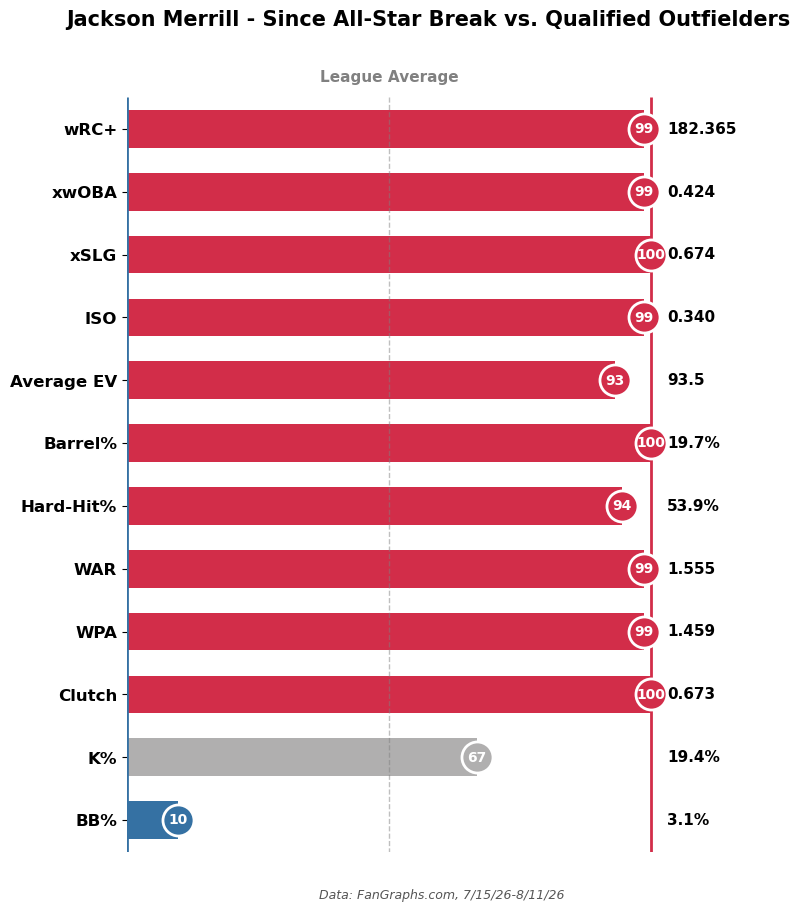

In [5]:
order = ['wRC+', 'xwOBA', 'xSLG', 'ISO', 'EV', 'Barrel%', 'HardHit%', 'WAR', 'WPA', 'Clutch', 'K%', 'BB%']
pctls = [merrill[l + '_pctl'] for l in order]
raws = [merrill[l] for l in order]

def get_color(p):
    if p >= 67:
        return '#D22D49'
    elif p >= 33:
        return '#B0AFAF'
    else:
        return '#3571A3'

colors = [get_color(p) for p in pctls]

fig, ax = plt.subplots(figsize=(9, 9.5))

y_pos = range(len(order))
bars = ax.barh(y_pos, pctls, color=colors, height=0.6, zorder=2)

label_display = {
    'HardHit%': 'Hard-Hit%',
    'EV': 'Average EV',
}

for i, (bar, p, raw, label) in enumerate(zip(bars, pctls, raws, order)):
    ax.scatter(p, i, s=500, color=colors[i], edgecolor='white', linewidth=2, zorder=3)
    ax.text(p, i, f"{int(round(p))}", ha='center', va='center', fontsize=10, fontweight='bold', color='white', zorder=4)
    if label in ['Barrel%', 'HardHit%', 'BB%', 'K%']:
        raw_str = f"{raw*100:.1f}%"
    elif label in ['EV']:
        raw_str = f"{raw:.1f}"
    else:
        raw_str = f"{raw:.3f}"
    ax.text(103, i, raw_str, ha='left', va='center', fontsize=11, fontweight='bold')

display_labels = [label_display.get(l, l) for l in order]
ax.set_yticks(y_pos)
ax.set_yticklabels(display_labels, fontsize=12, fontweight='bold')
ax.set_xlim(0, 115)
ax.set_ylim(-1.2, len(order)-0.5)
ax.invert_yaxis()

ax.vlines(0, -0.5, len(order)-0.5, color='#3571A3', linewidth=2)
ax.vlines(50, -0.5, len(order)-0.5, color='gray', linewidth=1, linestyle='--', alpha=0.5)
ax.vlines(100, -0.5, len(order)-0.5, color='#D22D49', linewidth=2)

ax.text(50, -0.7, 'League Average', ha='center', va='bottom', fontsize=11, fontweight='bold', color='gray')

ax.set_xticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.set_title("Jackson Merrill - Since All-Star Break vs. Qualified Outfielders",
             fontsize=15, fontweight='bold', pad=20)

fig.text(0.5, 0.01, "Data: FanGraphs.com, 7/15/26-8/11/26", ha='center', fontsize=9, style='italic', color='#555555')

plt.subplots_adjust(left=0.15, right=0.82, top=0.90, bottom=0.06)
plt.savefig('merrill_since_asb_OF_elite.png', dpi=200)
plt.show()